## Problem Statement:
The goal of this project is to develop a machine learning model that can predict whether an online shopper will complete a purchase during a session based on their browsing behavior, traffic source, and session characteristics. Using the Online Shoppers Intention dataset, we aim to classify user sessions as either resulting in a purchase or not, which can help e-commerce businesses enhance marketing strategies, improve user experience, and optimize conversion rates. This is a binary classification problem, where the model classifies each session into two categories: purchase or no purchase.

## Objective
To build a predictive model that accurately classifies online shopping sessions as purchase or non-purchase events using user behavior and session attributes, with the aim of supporting data-driven decision-making in e-commerce to improve customer conversion rates.

### Online Shoppers intentions dataset
```
1. "Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" and "Product Related Duration" represent the number of different types of pages visited by the visitor in that session and total time spent in each of these page categories.
2. The values of these features are derived from the URL information of the pages visited by the user and updated in real time when a user takes an action, e.g. moving from one page to another.
3.The "Bounce Rate", "Exit Rate" and "Page Value" features represent the metrics measured by "Google Analytics" for each page in the e-commerce site. 4.The value of "Bounce Rate" feature for a web page refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session.
5.The value of "Exit Rate" feature for a specific web page is calculated as for all pageviews to the page, the percentage that were the last in the session.
6.The "Page Value" feature represents the average value for a web page that a user visited before completing an e-commerce transaction. The "Special Day" feature indicates the closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction.
7.The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
8.The dataset also includes operating system, browser, region, traffic type, visitor type as returning or new visitor, a Boolean value indicating whether the date of the visit is weekend, and month of the year.
```

### Link of the dataset
https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset

### Import Necessary libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

### Read the csv file

In [2]:
data=pd.read_csv("online_shoppers_intention.csv")
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Shape
- In this dataset 12330 rows and 18 columns present

In [3]:
data.shape

(12330, 18)

### Duplicated values
- There are 125 duplicate values present in this data

In [4]:
data.duplicated().sum()

125

### Drop Duplicates
- Removing all duplicate records from the dataset to ensure data integrity and avoid redundancy during model training.

In [5]:
data.drop_duplicates(inplace=True)

### No duplicate values
- Verifying the dataset to confirm that all duplicate entries have been successfully removed.

In [6]:
data.duplicated().sum()

0

### Information about data
- 12205 entries in this data and 18 columns 2 bool, 7 float, 7 int, and 2 object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

### Null values
- There are no null values present in this data

In [8]:
data.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Unique values
Inspecting the dataset to identify the number of unique values present in each column, aiding in data understanding and preprocessing decisions.

In [9]:
for i in data.columns:
    print(i, data[i].nunique())

Administrative 27
Administrative_Duration 3335
Informational 17
Informational_Duration 1258
ProductRelated 311
ProductRelated_Duration 9551
BounceRates 1872
ExitRates 4777
PageValues 2704
SpecialDay 6
Month 10
OperatingSystems 8
Browser 13
Region 9
TrafficType 20
VisitorType 3
Weekend 2
Revenue 2


### Convert target feature to numerical

In [10]:
data["Revenue"]=data["Revenue"].replace({False:1,True:0}, regex=True)

C:\Users\Manisha\AppData\Local\Temp\ipykernel_13184\3762957475.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Revenue"]=data["Revenue"].replace({False:1,True:0}, regex=True)


### Find outliers
Several features in the dataset, including Administrative_Duration, ProductRelated_Duration, and ExitRates, contained zero values which were identified as outliers or missing data. These zero values were replaced with the median of each respective feature to retain the distribution while mitigating the impact of extreme values. This approach helps ensure the model trains on more meaningful data, improving its accuracy and robustness.

In [11]:
for i in data.select_dtypes(include="number").columns[:-1]:
    q1=data[i].quantile(0.25)
    q3=data[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-(1.5*iqr)
    upper=q3+(1.5*iqr)
    print(i, len(data[(data[i]< lower) | (data[i] > upper)]))
    data.loc[(data[i]<lower) | (data[i]>upper),i]=data[i].median()
    print(i, " :"  ,len(data[(data[i]<lower) | (data[i]>upper)]))

Administrative 404
Administrative  : 0
Administrative_Duration 1149
Administrative_Duration  : 0
Informational 2631
Informational  : 0
Informational_Duration 2405
Informational_Duration  : 0
ProductRelated 1007
ProductRelated  : 0
ProductRelated_Duration 951
ProductRelated_Duration  : 0
BounceRates 1428
BounceRates  : 0
ExitRates 1325
ExitRates  : 0
PageValues 2730
PageValues  : 0
SpecialDay 1249
SpecialDay  : 0
OperatingSystems 107
OperatingSystems  : 0
Browser 4322
Browser  : 0
Region 505
Region  : 0
TrafficType 2084
TrafficType  : 0


# Univariate Analysis

### Numerical Features
- ProductRelated features show a wider spread, indicating varying user interest in products.
- BounceRates and ExitRates are concentrated at lower values, reflecting relatively engaged sessions.
- Additionally, PageValues are mostly zero, implying few sessions result in revenue-related activity.
- Overall, the distributions reveal user behavior is highly skewed in several areas, with product-related features showing the most variability.

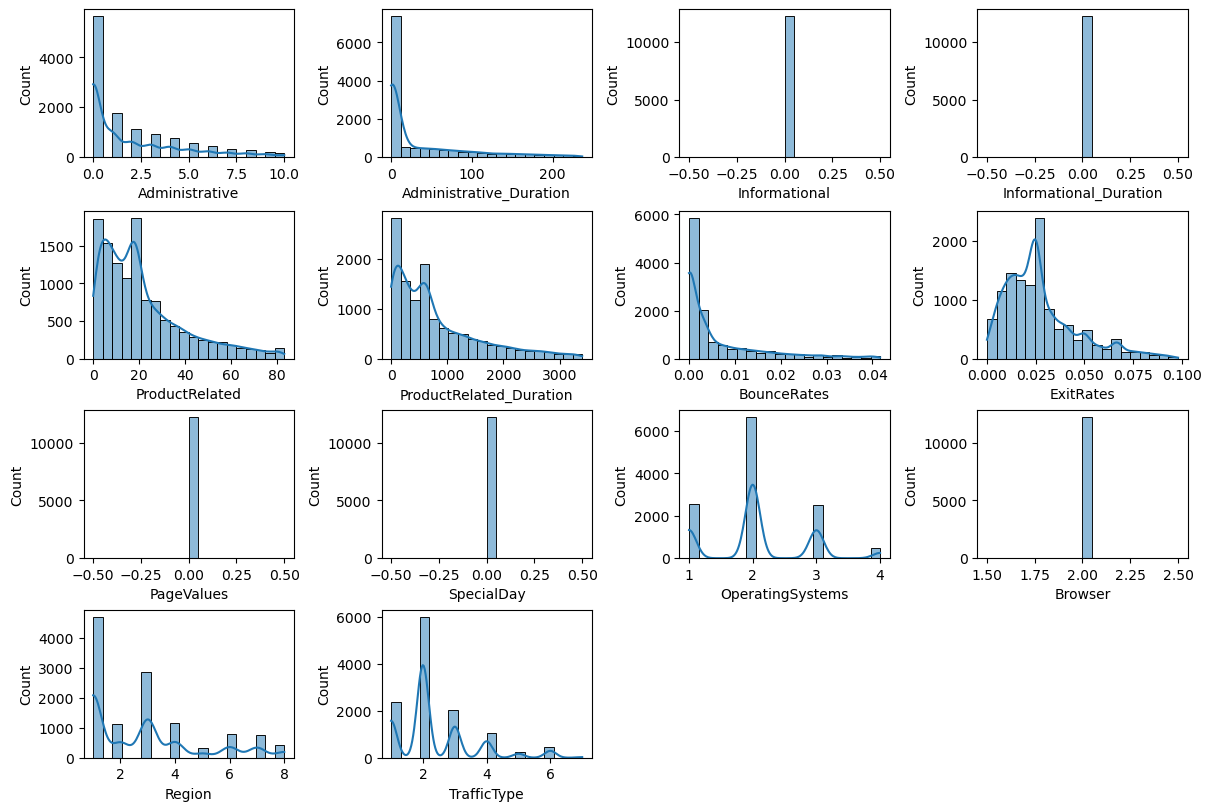

In [12]:
plt.figure(figsize=(12,8), layout = "constrained")
plt.subplot(4,4,1)
sns.histplot(x=data["Administrative"], kde=True, bins=20)
plt.subplot(4,4,2)
sns.histplot(x=data["Administrative_Duration"], kde=True, bins=20)
plt.subplot(4,4,3)
sns.histplot(x=data["Informational"], kde=True, bins=20)
plt.subplot(4,4,4)
sns.histplot(x=data["Informational_Duration"], kde=True, bins=20)
plt.subplot(4,4,5)
sns.histplot(x=data["ProductRelated"], kde=True, bins=20)
plt.subplot(4,4,6)
sns.histplot(x=data["ProductRelated_Duration"], kde=True, bins=20)
plt.subplot(4,4,7)
sns.histplot(x=data["BounceRates"], kde=True, bins=20)
plt.subplot(4,4,8)
sns.histplot(x=data["ExitRates"], kde=True, bins=20)
plt.subplot(4,4,9)
sns.histplot(x=data["PageValues"], kde=True, bins=20)
plt.subplot(4,4,10)
sns.histplot(x=data["SpecialDay"], kde=True, bins=20)
plt.subplot(4,4,11)
sns.histplot(x=data["OperatingSystems"], kde=True, bins=20)
plt.subplot(4,4,12)
sns.histplot(x=data["Browser"], kde=True, bins=20)
plt.subplot(4,4,13)
sns.histplot(x=data["Region"], kde=True, bins=20)
plt.subplot(4,4,14)
sns.histplot(x=data["TrafficType"], kde=True, bins=20)
plt.show()


- The boxplots reveal the presence of significant outliers in features like Administrative_Duration, Informational_Duration, ProductRelated_Duration, BounceRates, and ExitRates, indicating that a small number of users behave very differently from the majority.
- Most features have a compact interquartile range, suggesting consistent behavior for most users, while the presence of long upper whiskers in several plots confirms right-skewed distributions.
- These insights highlight the importance of handling outliers to ensure stable model performance.

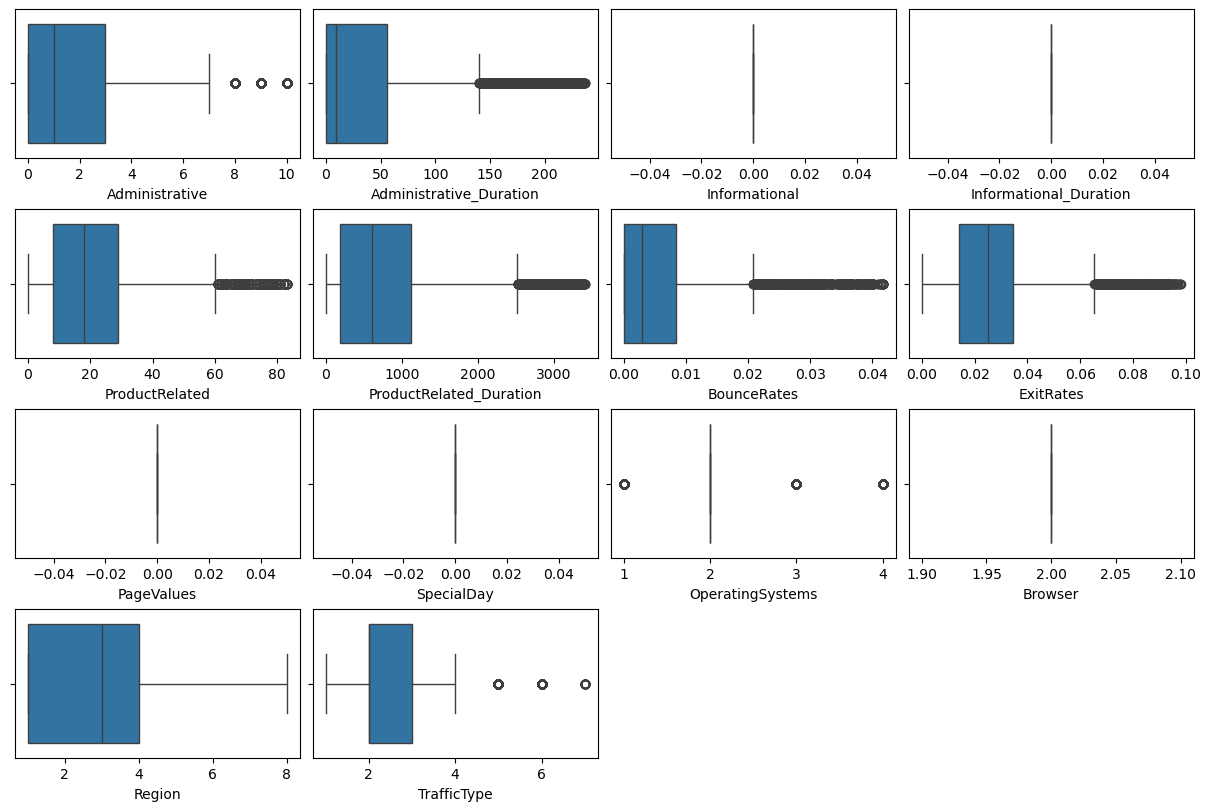

In [13]:
plt.figure(figsize=(12,8), layout = "constrained")
plt.subplot(4,4,1)
sns.boxplot(x=data["Administrative"])
plt.subplot(4,4,2)
sns.boxplot(x=data["Administrative_Duration"])
plt.subplot(4,4,3)
sns.boxplot(x=data["Informational"])
plt.subplot(4,4,4)
sns.boxplot(x=data["Informational_Duration"])
plt.subplot(4,4,5)
sns.boxplot(x=data["ProductRelated"])
plt.subplot(4,4,6)
sns.boxplot(x=data["ProductRelated_Duration"])
plt.subplot(4,4,7)
sns.boxplot(x=data["BounceRates"])
plt.subplot(4,4,8)
sns.boxplot(x=data["ExitRates"])
plt.subplot(4,4,9)
sns.boxplot(x=data["PageValues"])
plt.subplot(4,4,10)
sns.boxplot(x=data["SpecialDay"])
plt.subplot(4,4,11)
sns.boxplot(x=data["OperatingSystems"])
plt.subplot(4,4,12)
sns.boxplot(x=data["Browser"])
plt.subplot(4,4,13)
sns.boxplot(x=data["Region"])
plt.subplot(4,4,14)
sns.boxplot(x=data["TrafficType"])
plt.show()

### Categorical Features
**Month**
Most sessions occurred in May (3329) and November (2982), indicating peak user activity during these months, possibly due to seasonal or promotional events.

**VisitorType**
The majority of users are Returning Visitors (10,431), showing strong user retention.

New Visitors (1,693) and Other (81) make up a smaller portion, suggesting fewer first-time or unclassified sessions.

**Weekend**
The data shows a fairly balanced distribution of sessions between weekends and weekdays, suggesting consistent user activity throughout the week.

**Revenue**
The Revenue feature is highly imbalanced, with around 10,000 sessions resulting in purchases (1) and only 2,000 sessions without purchases (0).

This imbalance needs to be considered during model training to avoid bias toward the majority class.

In [154]:
for i in data.select_dtypes(include="object").columns:
    print(data[i].value_counts())

data["Weekend"].value_counts()
data["Revenue"].value_counts()

Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64


Revenue
1    10297
0     1908
Name: count, dtype: int64

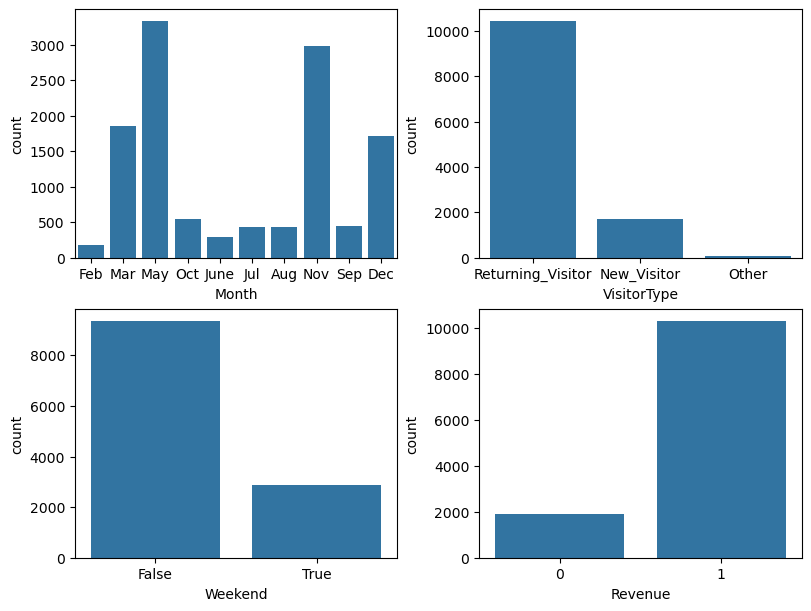

In [14]:
data.select_dtypes(include="object").columns
plt.figure(figsize=(8,6), layout = "constrained")
plt.subplot(2,2,1)
sns.countplot(x=data["Month"])
plt.subplot(2,2,2)
sns.countplot(x=data["VisitorType"])
plt.subplot(2,2,3)
sns.countplot(x=data["Weekend"])
plt.subplot(2,2,4)
sns.countplot(x=data["Revenue"])
plt.show()

In [68]:
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.002899,0.025,0.0,0.0,Feb,1,2,1,1,Returning_Visitor,False,1
1,0,0.0,0,0.0,2,64.000000,0.000000,0.025,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,1
2,0,0.0,0,0.0,1,0.000000,0.002899,0.025,0.0,0.0,Feb,4,2,3,3,Returning_Visitor,False,1
3,0,0.0,0,0.0,2,2.666667,0.002899,0.025,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,1
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050,0.0,0.0,Feb,3,2,1,4,Returning_Visitor,True,1


## Model Building
Separating the dataset into features (X) and target variable (y) to prepare for model training and evaluation

In [119]:
x=data.drop(["Revenue","Month","VisitorType"], axis=1)
y=data["Revenue"]

In [120]:
x.shape

(12205, 15)

In [121]:
y.shape

(12205,)

- The target variable Revenue is significantly imbalanced, with 10,297 sessions resulting in a purchase (label 1) and only 1,908 without a purchase (label 0).
- This imbalance may lead to biased model predictions toward the majority class, so techniques like resampling or class weighting should be considered to improve model performance.

In [122]:
y.value_counts()

Revenue
1    10297
0     1908
Name: count, dtype: int64

### Splitting data into training and testing

In [123]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

- Applying standard scaling to the independent variables to normalize the feature distributions and ensure all features contribute equally to the model.

In [124]:
scaled=StandardScaler()
x_scaled_train=scaled.fit_transform(x_train)
x_scaled_test=scaled.transform(x_test)

- A K-Nearest Neighbors (KNN) classifier was trained using the scaled training data with k=3.
- By considering the 3 closest neighbors for each prediction, the model aims to classify user sessions based on similarity in behavior patterns.
- This step enables the model to learn from labeled data and prepare for evaluating its ability to predict purchase intentions.

In [125]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_scaled_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [126]:
y_pred=knn.predict(x_scaled_test)

- The KNN model achieved an accuracy of 80.09%, indicating it correctly predicted the purchase intention for the majority of sessions. The precision of 85.96% suggests that when the model predicts a user will make a purchase, it is correct most of the time. This high precision is especially valuable in minimizing false positives, which is crucial in applications like targeted marketing or personalized recommendations.

In [127]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.8009012699713233
0.8596250571559213


- While the model performs well, the presence of false positives and false negatives indicates areas for improvement, especially in reducing missed purchase opportunities (false negatives) and misclassifying non-purchase sessions (false positives).

In [128]:
confusion_matrix(y_test, y_pred)

array([[  75,  307],
       [ 179, 1880]], dtype=int64)

- the model performs well for predicting purchases but struggles with predicting non-purchase sessions, indicating potential class imbalance issues that could be addressed by techniques like oversampling or adjusting class weights.

In [129]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.30      0.20      0.24       382
           1       0.86      0.91      0.89      2059

    accuracy                           0.80      2441
   macro avg       0.58      0.55      0.56      2441
weighted avg       0.77      0.80      0.78      2441



In [130]:
score=[]
for i in range(1,30):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_scaled_train, y_train)
    y_pred=knn.predict(x_scaled_test)
    score.append(accuracy_score(y_test, y_pred))

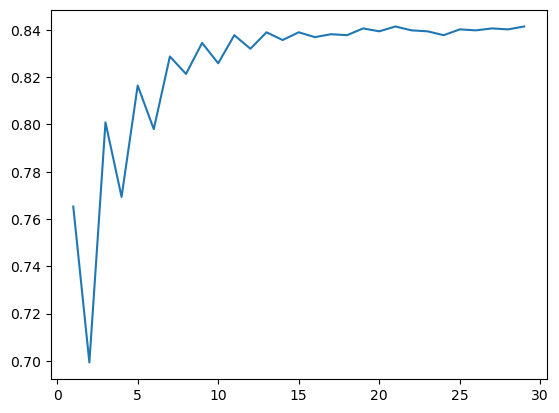

In [131]:
plt.plot(range(1,30), score)

### SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) is a technique used to address class imbalance by generating synthetic samples for the minority class, helping the model learn better and improving performance on underrepresented classes. This method helps balance the data by creating new, realistic examples rather than just duplicating existing ones.

In [132]:
smote=SMOTE()

In [133]:
x_resampled, y_resampled=smote.fit_resample(x_scaled_train, y_train)

In [134]:
y_resampled.value_counts()

Revenue
1    8238
0    8238
Name: count, dtype: int64

In [135]:
knn=KNeighborsClassifier()
knn.fit(x_resampled, y_resampled)

KNeighborsClassifier()

In [136]:
y_test_pred=knn.predict(x_scaled_test)

- After applying SMOTE to balance the dataset, the model achieved an accuracy of 65.06%, a decrease from the previous accuracy of 80.09%. However, the precision for the positive class (purchases) significantly improved to 88.85%, indicating that the model is now more reliable in predicting purchases. While the overall accuracy decreased, the improvement in precision suggests a better handling of the minority class (purchases), reducing the number of false positives.

In [137]:
print(accuracy_score(y_test, y_test_pred))
print(precision_score(y_test, y_test_pred))

0.6505530520278574
0.8885309278350515


In [138]:
confusion_matrix(y_test, y_test_pred)

array([[ 209,  173],
       [ 680, 1379]], dtype=int64)

In [139]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.24      0.55      0.33       382
           1       0.89      0.67      0.76      2059

    accuracy                           0.65      2441
   macro avg       0.56      0.61      0.55      2441
weighted avg       0.79      0.65      0.70      2441



- After training the KNN model, two sample inputs are used for prediction. The model predicts the likelihood of a purchase for both cases:
- Sample 1: The first sample, which seems to have lower activity (such as no time spent on Product Related pages), results in a prediction of No Purchase.
- Sample 2: The second sample, with more interaction (higher time on Product Related pages), predicts a Will Purchase, indicating a higher likelihood of purchase based on the user's behavior.

In [152]:
sample=[[0,0.0,0,0.0,1,0.000000,0.002899,0.025000,0.0,0.0,1,2,1,1,False]]
sample1=[[1,56.5,0,0.0,19,1089.750000,0.000000,0.003509,0.0,0.0,2,2,7,2,True]]
prediction=knn.predict(sample)
prediction1=knn.predict(sample1)
print("Prediction:", "Will Purchase" if prediction[0] == 1 else "No Purchase")
print("Prediction:", "Will Purchase" if prediction1[0] == 1 else "No Purchase")

Prediction: No Purchase
Prediction: Will Purchase


## Conclusion
In this analysis, we used a K-Nearest Neighbors (KNN) classifier to predict user purchase intentions based on various website engagement features. After preprocessing and handling data imbalance with SMOTE, the model achieved an accuracy of 65.06% and a precision of 88.85% for predicting purchases. Despite the decrease in overall accuracy after balancing, the improved precision highlights the model's enhanced ability to correctly identify purchase sessions. The confusion matrix and classification metrics further illustrated the model's performance across different classes, showing the importance of addressing class imbalance. Ultimately, the model is better at identifying purchases, but more work is needed to refine predictions for non-purchase sessions.